In this step, we import the required Python libraries for data manipulation, visualization, and machine learning.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import warnings
warnings.filterwarnings("ignore")


The dataset contains historical flight booking information including airline, route, duration, stops, and price.


In [4]:
df = pd.read_excel("flight.xlsx")
df.head()


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [5]:
df.shape


(10683, 11)

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


Missing values can negatively affect model performance.  
We check and remove rows with missing values.


In [8]:
df.isnull().sum()


Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [9]:
df.dropna(inplace=True)


# Feature Engineering

Date_of_Journey is converted into Journey Day and Journey Month because machine learning models cannot interpret dates directly.


In [5]:
df["Journey_Day"] = pd.to_datetime(df["Date_of_Journey"], format="%d/%m/%Y").dt.day
df["Journey_Month"] = pd.to_datetime(df["Date_of_Journey"], format="%d/%m/%Y").dt.month
df.drop("Date_of_Journey", axis=1, inplace=True)


Departure time is split into hour and minute to capture time-based pricing patterns.


In [6]:
df["Dep_Hour"] = pd.to_datetime(df["Dep_Time"]).dt.hour
df["Dep_Min"] = pd.to_datetime(df["Dep_Time"]).dt.minute
df.drop("Dep_Time", axis=1, inplace=True)


Arrival time is also split into hour and minute for better learning by the model.


In [7]:
df["Arrival_Hour"] = pd.to_datetime(df["Arrival_Time"]).dt.hour
df["Arrival_Min"] = pd.to_datetime(df["Arrival_Time"]).dt.minute
df.drop("Arrival_Time", axis=1, inplace=True)


Duration is originally in text format (e.g., '2h 50m').  
convert it into numerical hours and minutes.


In [8]:
duration = list(df["Duration"])

for i in range(len(duration)):
    if len(duration[i].split()) != 2:
        if "h" in duration[i]:
            duration[i] = duration[i] + " 0m"
        else:
            duration[i] = "0h " + duration[i]

df["Duration_Hours"] = [int(i.split("h")[0]) for i in duration]
df["Duration_Mins"] = [int(i.split("m")[0].split()[-1]) for i in duration]

df.drop("Duration", axis=1, inplace=True)


Total_Stops is an ordinal categorical variable and is converted into numeric form.


In [9]:
df["Total_Stops"].replace({
    "non-stop": 0,
    "1 stop": 1,
    "2 stops": 2,
    "3 stops": 3,
    "4 stops": 4
}, inplace=True)


Route and Additional_Info are dropped as they do not contribute significantly to prediction.


In [10]:
df.drop(["Route", "Additional_Info"], axis=1, inplace=True)


# One Hot Encoding

Categorical variables are converted into numerical format using one-hot encoding.


In [11]:
df = pd.get_dummies(df, drop_first=True)
df.head()


,Total_Stops,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_Hours,Duration_Mins,...,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0.0,3897,24,3,22,20,1,10,2,50,...,False,False,False,False,False,False,False,False,False,True
1,2.0,7662,1,5,5,50,13,15,7,25,...,False,False,False,True,False,False,False,False,False,False
2,2.0,13882,9,6,9,25,4,25,19,0,...,False,False,True,False,False,True,False,False,False,False
3,1.0,6218,12,5,18,5,23,30,5,25,...,False,False,False,True,False,False,False,False,False,False
4,1.0,13302,1,3,16,50,21,35,4,45,...,False,False,False,False,False,False,False,False,False,True


# EDA

This plot shows how flight prices are distributed across the dataset.


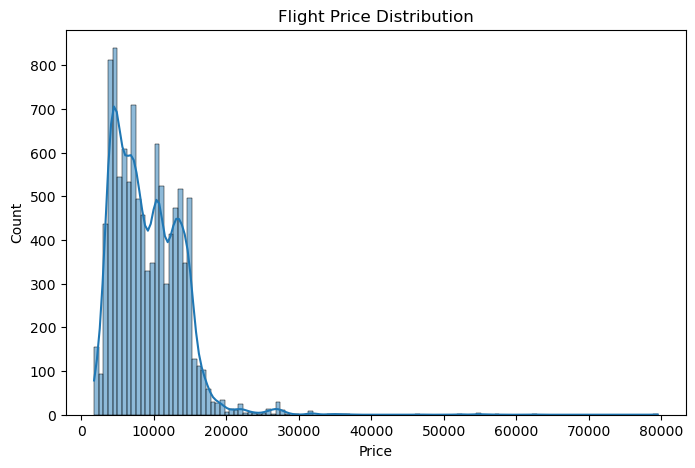

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["Price"], kde=True)
plt.title("Flight Price Distribution")
plt.show()


Flights with more stops generally have lower prices.


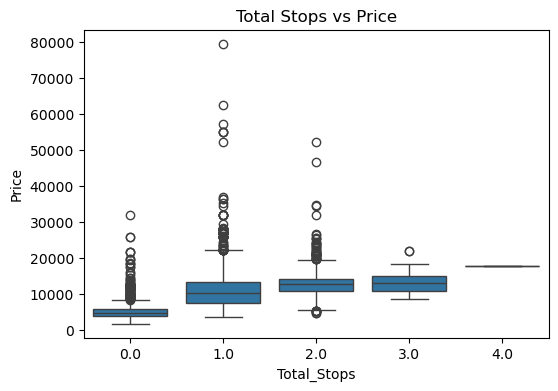

In [13]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Total_Stops", y="Price", data=df)
plt.title("Total Stops vs Price")
plt.show()


This heatmap shows correlation between features and the target variable.


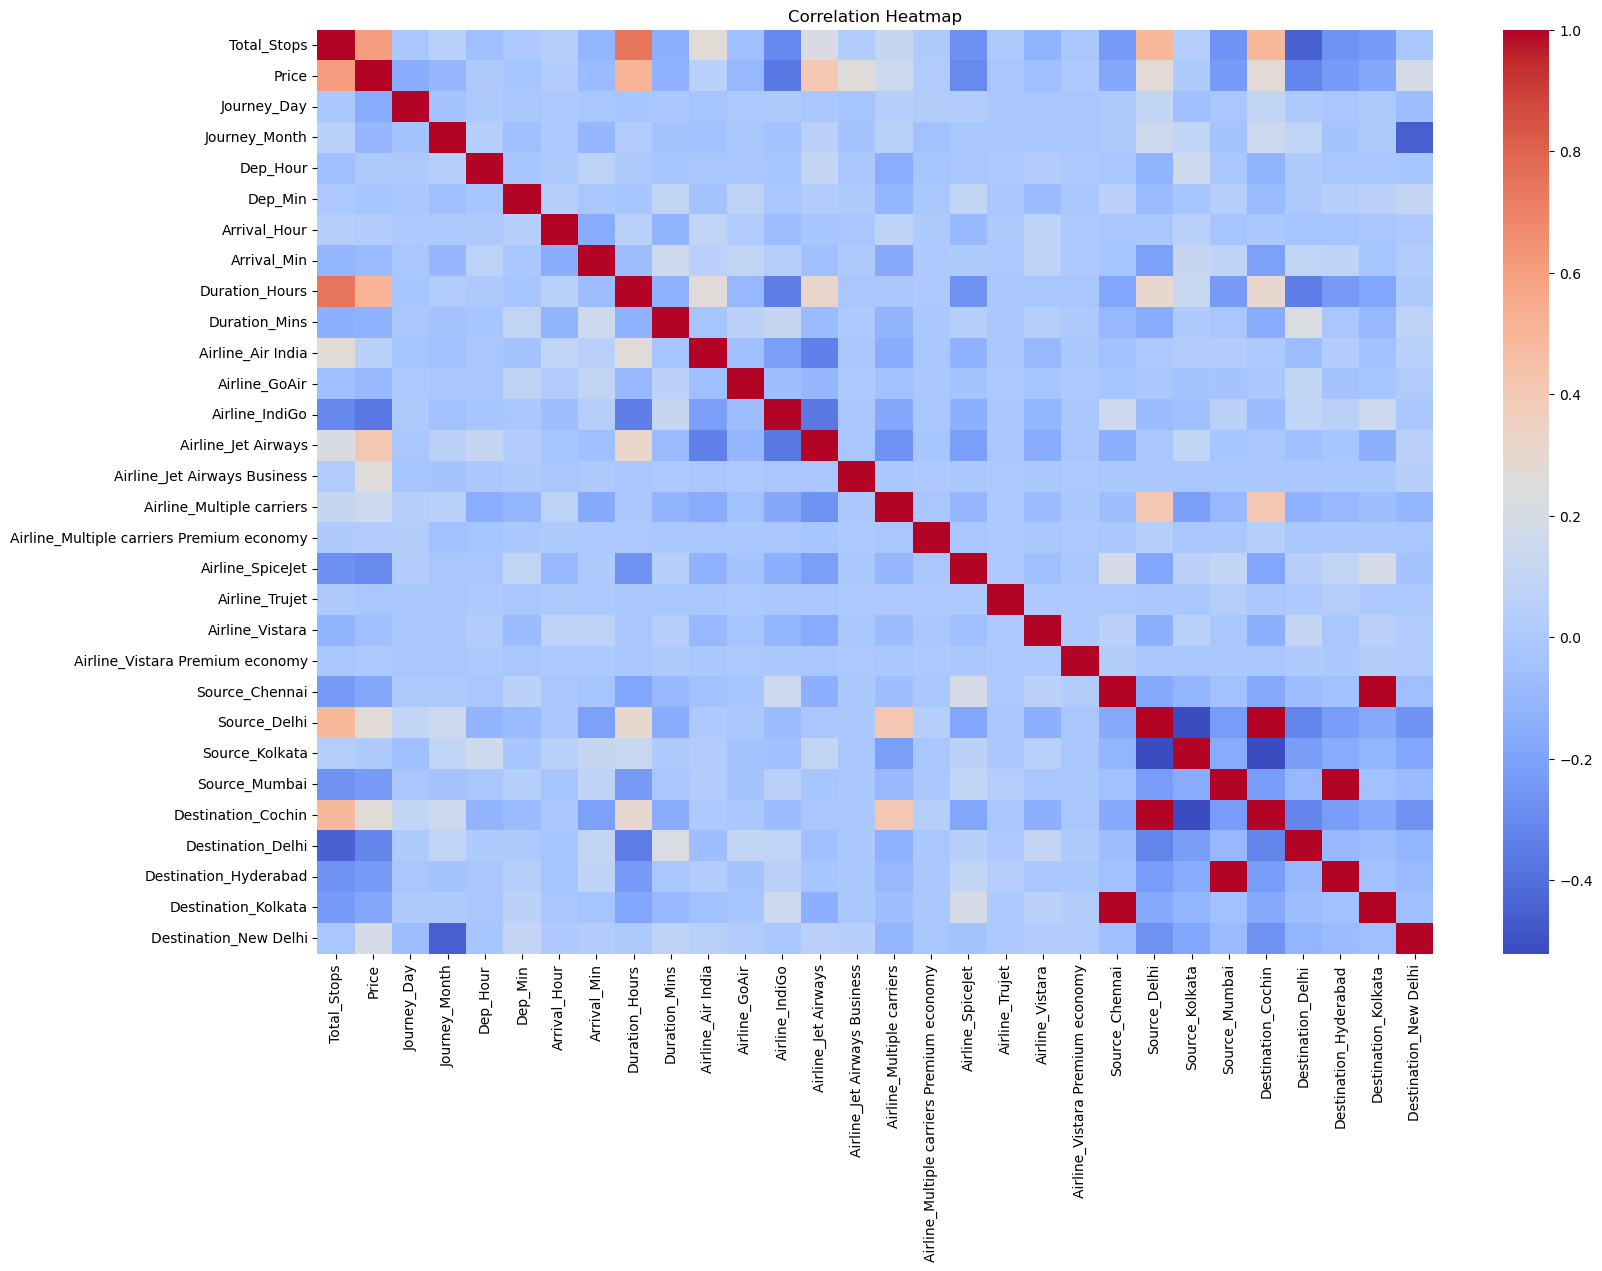

In [14]:
plt.figure(figsize=(18,12))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


# Conclusion
- Data cleaned and transformed successfully  
- Important pricing patterns identified  
- Dataset prepared for machine learning


# PREDICTIVE MODEL CREATION

The dataset is split into training and testing sets to evaluate model performance.


In [15]:
X = df.drop("Price", axis=1)
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Linear Regression

Linear Regression is used as a baseline model.


In [19]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

print("Linear Regression R2:", r2_score(y_test, pred_lr))


ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

## Decision Tree Regressor

Decision Tree captures non-linear relationships but may overfit.


In [17]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)

print("Decision Tree R2:", r2_score(y_test, pred_dt))


Decision Tree R2: 0.6777726418626546


## Random Forest Regressor

Random Forest reduces overfitting by averaging multiple decision trees.


In [18]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print("Random Forest R2:", r2_score(y_test, pred_rf))


Random Forest R2: 0.7864676180614576


## Gradient Boosting Regressor

Gradient Boosting improves performance by learning from previous errors.


In [48]:
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)

print("Gradient Boosting R2:", r2_score(y_test, pred_gb))


Gradient Boosting R2: 0.7856246475690609


# Model Comparison

The performance of all models is compared using R² score.


In [20]:
model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest", "Gradient Boosting"],
    "R2 Score": [
        r2_score(y_test, pred_lr),
        r2_score(y_test, pred_dt),
        r2_score(y_test, pred_rf),
        r2_score(y_test, pred_gb)
    ]
})

model_comparison


NameError: name 'pred_lr' is not defined

# Final Model Selection
Random Forest Regressor is selected as the final model due to its superior performance and robustness.


In [53]:
print("MAE:", mean_absolute_error(y_test, pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_rf)))


MAE: 1176.1679126309011
RMSE: 2089.372802628276


# hyper parameter tuning

In [21]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}


In [22]:
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)


Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, verbose=2)

In [26]:
rf_random.best_params_


{'n_estimators': 300,
 'min_samples_split': 10,
 'min_samples_leaf': 2,
 'max_depth': 20}

In [27]:
final_rf = rf_random.best_estimator_


In [28]:
final_rf_pred = final_rf.predict(X_test)

print("Tuned Random Forest R2 Score:", r2_score(y_test, final_rf_pred))
print("Tuned MAE:", mean_absolute_error(y_test, final_rf_pred))
print("Tuned RMSE:", np.sqrt(mean_squared_error(y_test, final_rf_pred)))


Tuned Random Forest R2 Score: 0.8045719041585513
Tuned MAE: 1160.667734160845
Tuned RMSE: 2033.7240684799428


In [29]:
comparison = pd.DataFrame({
    "Model": ["Random Forest (Default)", "Random Forest (Tuned)"],
    "R2 Score": [
        r2_score(y_test, pred_rf),
        r2_score(y_test, final_rf_pred)
    ]
})

comparison


,Model,R2 Score
0,Random Forest (Default),0.786468
1,Random Forest (Tuned),0.804572


# Final Conclusion
- Random Forest outperformed all other models
- Hyperparameter tuning improved prediction accuracy
- Overfitting was reduced after tuning
- The tuned Random Forest model is selected for production use



- Task-1: Complete data analysis and EDA performed  
- Task-2: Predictive model built and evaluated  
- Random Forest selected as best model  
- Model ready for deployment

In [31]:
import joblib
joblib.dump(rf,"model.pkl")

['model.pkl']

In [32]:
X_train.columns


Index(['Total_Stops', 'Journey_Day', 'Journey_Month', 'Dep_Hour', 'Dep_Min',
       'Arrival_Hour', 'Arrival_Min', 'Duration_Hours', 'Duration_Mins',
       'Airline_Air India', 'Airline_GoAir', 'Airline_IndiGo',
       'Airline_Jet Airways', 'Airline_Jet Airways Business',
       'Airline_Multiple carriers',
       'Airline_Multiple carriers Premium economy', 'Airline_SpiceJet',
       'Airline_Trujet', 'Airline_Vistara', 'Airline_Vistara Premium economy',
       'Source_Chennai', 'Source_Delhi', 'Source_Kolkata', 'Source_Mumbai',
       'Destination_Cochin', 'Destination_Delhi', 'Destination_Hyderabad',
       'Destination_Kolkata', 'Destination_New Delhi'],
      dtype='object')